#**INGRESOS CIERRE**


##**INITIAL DATA INSPECTION**


In [3]:
import pandas as pd

df_cierre = pd.read_excel("uc3m-presupuesto-de-ingresos-cierre-2023.xlsx")

print("Dataset shape:", df_cierre.shape)
print("Columns:")
print(df_cierre.columns)

print("Data types:")
print(df_cierre.dtypes)

print("Missing values:")
print(df_cierre.isnull().sum().sort_values(ascending=False).head(15))

df_cierre.head()


Dataset shape: (3267, 29)
Columns:
Index(['cod_universidad', 'des_universidad', 'anio', 'cod_capitulo',
       'des_capitulo', 'cod_articulo', 'des_articulo', 'cod_concepto',
       'des_concepto', 'cod_subconcepto', 'des_subconcepto', 'cod_partida',
       'des_partida', 'cod_seccion', 'des_seccion', 'cod_servicio',
       'des_servicio', 'cod_unidad_de_coste', 'des_unidad_de_coste',
       'cod_organica_libre_1', 'des_organica_libre_1', 'cod_organica_libre_2',
       'des_organica_libre_2', 'fecha_referencia', 'credito_inicial',
       'modificaciones', 'credito_total', 'derechos_reconocidos_netos',
       'recaudacion_neta'],
      dtype='object')
Data types:
cod_universidad                 int64
des_universidad                object
anio                            int64
cod_capitulo                    int64
des_capitulo                   object
cod_articulo                    int64
des_articulo                   object
cod_concepto                    int64
des_concepto             

,cod_universidad,des_universidad,anio,cod_capitulo,des_capitulo,cod_articulo,des_articulo,cod_concepto,des_concepto,cod_subconcepto,...,cod_organica_libre_1,des_organica_libre_1,cod_organica_libre_2,des_organica_libre_2,fecha_referencia,credito_inicial,modificaciones,credito_total,derechos_reconocidos_netos,recaudacion_neta
0,36,Universidad Carlos III de Madrid,2023,4,TRANSFERENCIAS CORRIENTES,45,DE COMUNIDADES AUTONOMAS,450,TRANSFERENCIAS CORRIENTES DE COMUNIDADES AUTON...,450.03,...,(no informado),(no informado),(no informado),(no informado),20231231,0.0,0.0,0.0,24000.00,24000.00
1,36,Universidad Carlos III de Madrid,2023,4,TRANSFERENCIAS CORRIENTES,45,DE COMUNIDADES AUTONOMAS,450,TRANSFERENCIAS CORRIENTES DE COMUNIDADES AUTON...,450.03,...,(no informado),(no informado),(no informado),(no informado),20231231,24000.0,0.0,24000.0,0.00,0.00
2,36,Universidad Carlos III de Madrid,2023,3,"TASAS, PRECIOS PUBLICOS Y OTROS INGRESOS",38,REINTEGROS DE OPERACIONES CORRIENTES,380,REINTEGROS DE EJERCICIOS CERRADOS,(no informado),...,(no informado),(no informado),(no informado),(no informado),20231231,0.0,0.0,0.0,222.98,222.98
3,36,Universidad Carlos III de Madrid,2023,3,"TASAS, PRECIOS PUBLICOS Y OTROS INGRESOS",39,INGRESOS DIVERSOS,399,INGRESOS DIVERSOS,399.99,...,(no informado),(no informado),(no informado),(no informado),20231231,0.0,0.0,0.0,41.30,0.00
4,36,Universidad Carlos III de Madrid,2023,3,"TASAS, PRECIOS PUBLICOS Y OTROS INGRESOS",39,INGRESOS DIVERSOS,399,INGRESOS DIVERSOS,399.99,...,(no informado),(no informado),(no informado),(no informado),20231231,0.0,0.0,0.0,16877.24,16877.24


##**DATA PREPROCESSING**


In [5]:
import pandas as pd

# -----------------------------
# Drop irrelevant columns
# -----------------------------
cols_to_drop = [
    "cod_partida",
    "des_partida",
    "cod_seccion",
    "des_seccion",
    "cod_unidad_de_coste",
    "des_unidad_de_coste",
    "cod_organica_libre_1",
    "des_organica_libre_1",
    "cod_organica_libre_2",
    "des_organica_libre_2",
    "fecha_referencia"
]

df_cierre = df_cierre.drop(columns=cols_to_drop)

# -----------------------------
# Standardize text columns
# -----------------------------
text_cols = df_cierre.select_dtypes(include="object").columns

for col in text_cols:
    df_cierre[col] = df_cierre[col].astype(str).str.strip()

# -----------------------------
# Convert numeric columns
# -----------------------------
numeric_cols = [
    "credito_inicial",
    "modificaciones",
    "credito_total",
    "derechos_reconocidos_netos",
    "recaudacion_neta"
]

df_cierre[numeric_cols] = df_cierre[numeric_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# Check result
# -----------------------------
print("Clean dataset shape:", df_cierre.shape)

print("Missing values:")
print(df_cierre.isnull().sum().sort_values(ascending=False).head(15))

df_cierre.head()

# -----------------------------
# Export cleaned dataset
# -----------------------------
df_cierre.to_csv("uc3m_ingresos_cierre_clean.csv", index=False)


Clean dataset shape: (3267, 18)
Missing values:
cod_universidad    0
des_universidad    0
anio               0
cod_capitulo       0
des_capitulo       0
cod_articulo       0
des_articulo       0
cod_concepto       0
des_concepto       0
cod_subconcepto    0
des_subconcepto    0
cod_servicio       0
des_servicio       0
credito_inicial    0
modificaciones     0
dtype: int64


##**SHORT EDA**


In [6]:
# Basic information about the dataset
df_cierre.info()

# Descriptive statistics for numeric variables
df_cierre.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3267 entries, 0 to 3266
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_universidad             3267 non-null   int64  
 1   des_universidad             3267 non-null   object 
 2   anio                        3267 non-null   int64  
 3   cod_capitulo                3267 non-null   int64  
 4   des_capitulo                3267 non-null   object 
 5   cod_articulo                3267 non-null   int64  
 6   des_articulo                3267 non-null   object 
 7   cod_concepto                3267 non-null   int64  
 8   des_concepto                3267 non-null   object 
 9   cod_subconcepto             3267 non-null   object 
 10  des_subconcepto             3267 non-null   object 
 11  cod_servicio                3267 non-null   object 
 12  des_servicio                3267 non-null   object 
 13  credito_inicial             3267 

,cod_universidad,anio,cod_capitulo,cod_articulo,cod_concepto,credito_inicial,modificaciones,credito_total,derechos_reconocidos_netos,recaudacion_neta
count,3267.0,3267.0,3267.000000,3267.000000,3267.000000,3.267000e+03,3.267000e+03,3.267000e+03,3.267000e+03,3.267000e+03
mean,36.0,2023.0,6.246097,65.286807,657.977349,7.610141e+04,1.478674e+04,9.088815e+04,7.806328e+04,7.440245e+04
std,0.0,0.0,1.587047,16.211329,162.625734,1.849629e+06,3.572322e+05,1.883213e+06,1.856219e+06,1.852902e+06
min,36.0,2023.0,3.000000,31.000000,310.000000,0.000000e+00,0.000000e+00,0.000000e+00,-1.588055e+06,-1.588055e+06
25%,36.0,2023.0,5.000000,54.000000,540.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,6.605000e+00
50%,36.0,2023.0,7.000000,70.000000,709.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.603900e+02,3.665800e+02
75%,36.0,2023.0,7.000000,77.000000,770.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.688195e+03,3.103330e+03
max,36.0,2023.0,9.000000,91.000000,911.000000,9.995288e+07,1.561378e+07,9.995288e+07,1.004052e+08,1.004052e+08


In [7]:
# Distribution by chapter
df_cierre["des_capitulo"].value_counts()


,count
des_capitulo,
TRANSFERENCIAS DE CAPITAL,2106
"TASAS, PRECIOS PUBLICOS Y OTROS INGRESOS",409
ACTIVOS FINANCIEROS,323
TRANSFERENCIAS CORRIENTES,300
INGRESOS PATRIMONIALES,127
PASIVOS FINANCIEROS,2


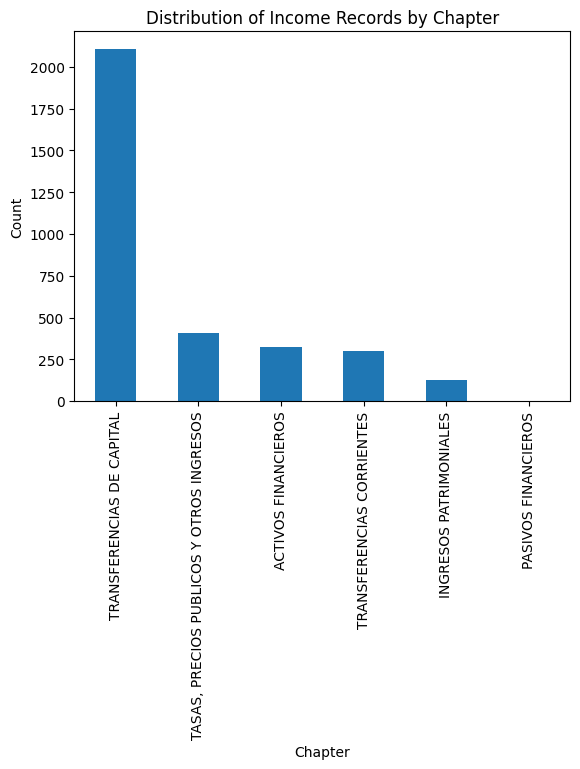

In [8]:
import matplotlib.pyplot as plt

df_cierre["des_capitulo"].value_counts().plot(kind="bar")
plt.title("Distribution of Income Records by Chapter")
plt.xlabel("Chapter")
plt.ylabel("Count")
plt.show()


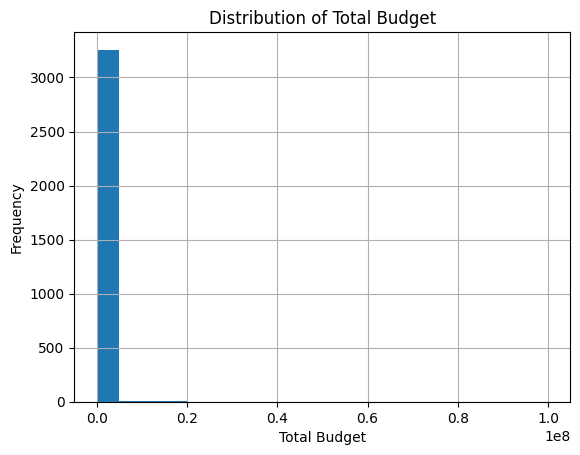

In [9]:
# Distribution of total budget values

df_cierre["credito_total"].hist(bins=20)

plt.title("Distribution of Total Budget")
plt.xlabel("Total Budget")
plt.ylabel("Frequency")
plt.show()


In [10]:
# Main services represented

df_cierre["des_servicio"].value_counts().head(10)


,count
des_servicio,
Centros actividad intercampus,2655
Campus de Getafe,355
Parque Cientifico,144
Campus de Leganés,81
Campus Madrid-Puerta de Toledo,28
Campus de Colmenarejo,4


In [11]:
# Main concepts represented

df_cierre["des_concepto"].value_counts().head(10)


,count
des_concepto,
OTRAS TRANSFERENCIAS DE CAPITAL,1511
TRANSFERENCIAS DE CAPITAL EMPRESAS PRIVADAS,334
REMANENTES DE TESORERIA,321
INGRESOS PROCEDENTES DE PRECIOS PÚBLICOS EN CONC. MATRICULA TIT. OF. CUR.,217
INGRESO POR USO DE INSTALACIONES,114
OTRAS DEL EXTERIOR,105
INGRESOS DE EMPRESAS PRIVADAS,104
TRANSFERENCIAS DE CAPITAL DE FAMILIAS E INSTITUCIONES SIN FINES DE LUCRO,61
INGRESOS INVESTIGACION,60


In [12]:
# Main subconcepts represented

df_cierre["des_subconcepto"].value_counts().head(10)


,count
des_subconcepto,
OTROS INGRESOS PARA INVESTIGACION,1511
(no informado),422
INGRESOS DE EMPRESAS PRIVADAS PARA INVESTIGACION,334
REMANENTE CORRIENTE,173
INGRESOS POR MATRICULAS DE MASTERES P. Y CURSOS,122
OTRAS TRANSF. DEL EXTERIOR,105
ALQUILER DE AULAS E INSTALACIONES,86
REMANENTE DE INVESTIGACION,84
INGRESOS MATRICULAS OFICIALES,74
